# Improving Coherence in a 4-Qubit System

This notebook systematically explores every lever available to improve $T_1$ and $T_2$,  
starting from the Josephson junction itself and working outward to resonator design, materials, and operating conditions.

---

## Diagnosis of the baseline device

From the 4-qubit Lindblad notebook, the baseline device has:

| Qubit | $T_1$ | $T_2$ | $T_2/2T_1$ | Purcell | TLS | QP |
|---|---|---|---|---|---|---|
| Q1 (5.79 GHz) | 14.7 μs | 25.3 μs | 0.86 | **68%** | 16% | 16% |
| Q2 (5.26 GHz) | 23.4 μs | 37.9 μs | 0.81 | **55%** | 23% | 22% |
| Q3 (4.73 GHz) | 32.8 μs | 50.6 μs | 0.77 | 44% | **29%** | 26% |
| Q4 (4.25 GHz) | 43.0 μs | 63.5 μs | 0.74 | 36% | **34%** | 30% |

**Regime: $T_1$-limited** — dephasing contributes only 15–25% to $T_2$; fixing $T_\varphi$ alone helps little.  
**Dominant $T_1$ channel: Purcell** for Q1/Q2; TLS and QP grow for lower-frequency qubits.

---

## Improvement levers (from junction outward)

| Lever | Parameter | Physical origin | Expected gain |
|---|---|---|---|
| 1. Junction critical current | $I_c$, $R_N$ | Ambegaokar-Baratoff | Reduces $\omega_{01}$, $E_J$, TLS+QP rates |
| 2. Shunting capacitor | $C_\text{shunt}$ | Pad geometry | Controls $E_C$, anharmonicity |
| 3. Purcell filter | $\kappa_f$ | Output line design | Suppresses $\Gamma_P$ by $10^{2}$–$10^3\times$ |
| 4. Resonator detuning | $\Delta_{qr}$ | Resonator frequency | Reduces $\Gamma_P \propto 1/\Delta_{qr}^2$ |
| 5. Surface oxide quality | $\tan\delta$ | Material (Ta vs Al) | 3–10× TLS improvement |
| 6. Capacitor geometry | $p_\text{surf}$ | Pad shape/size | Reduces TLS participation |
| 7. Quasiparticle shielding | $x_\text{qp}$ | IR shielding, phonon traps | Reduces QP rate |
| 8. Flux sweet spot | $\Phi/\Phi_0$ | Operating point | Eliminates 1/f flux dephasing |

---
## Structure
1. Baseline device (reproduce 4-qubit results)  
2. Lever 1: Junction critical current $I_c$  
3. Lever 2: Shunting capacitor $C_\text{shunt}$  
4. Lever 3: Purcell filter  
5. Lever 4: Resonator detuning $\Delta_{qr}$  
6. Lever 5+6: Materials — $\tan\delta$ and $p_\text{surf}$  
7. Lever 7: Quasiparticle suppression  
8. Lever 8: Flux sweet spot  
9. Summary table: all levers with gain factors and constraints  
10. Visual summary: gain per lever and sequential improvement path  
11. Why combined optimisation is not realistic: conflicts between levers  
12. Final printed summary and diagnostic workflow  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize, curve_fit
import os
import qutip as qt

OUTDIR = os.getcwd()
plt.rcParams.update({'font.size':12,'axes.labelsize':13,'axes.titlesize':13,
                     'figure.dpi':110,'lines.linewidth':2})
print('Imports OK')

Imports OK


---
## 1. Baseline Device

Reproduce the four-qubit coherence rates using the master `compute_coherence` function.  
This function is the core engine: given any set of device parameters, it returns $T_1$, $T_2$, and the channel breakdown for all 4 qubits.

In [2]:
# ── Physical constants ────────────────────────────────────────────────────────
hbar     = 1.0545718e-34
h        = 2*np.pi*hbar
e        = 1.6021766e-19
kB       = 1.3806503e-23
Phi0     = h/(2*e)
Delta_sc = 170e-6*e    # Al gap [MATERIAL]

# ── Master coherence function ─────────────────────────────────────────────────
def compute_qubit_coherence(
        R_N, C_J, C_sh,        # [GEOMETRY] junction + capacitor
        f_res, kappa, C_c,     # [GEOMETRY+OPERATING] resonator
        C_r,                   # [GEOMETRY] resonator cap
        p_surf, tan_delta,     # [MEASURED] TLS
        x_qp,                  # [MEASURED] quasiparticles
        A_flux, flux_bias,     # [MEASURED+OPERATING] 1/f noise
        T_fridge,              # [OPERATING] temperature
        purcell_filter=False,  # [OPERATING] filter on/off
        kappa_filter=None,     # [GEOMETRY] filter bandwidth
    ):
    """
    Compute T1, T2, Tphi and channel breakdown for one qubit.
    Returns dict with all rates and times.
    """
    # Junction → E_J, E_C
    E_J  = np.pi*hbar*Delta_sc/(4*e**2*R_N)
    C_S  = C_J + C_sh
    E_C  = e**2/(2*C_S)
    I_c  = np.pi*Delta_sc/(2*e*R_N)   # critical current

    # Transmon frequencies
    omega = (np.sqrt(8*E_J*E_C) - E_C) / hbar
    alpha = -E_C / hbar

    # Resonator
    omega_r  = 2*np.pi*f_res
    Delta_qr = omega - omega_r
    g_r      = (C_c/2)*np.sqrt(omega*omega_r/(C_S*C_r))
    chi      = g_r**2/Delta_qr
    n_th     = 1/(np.exp(hbar*omega_r/(kB*T_fridge))-1)

    # T1 channels
    Gamma_P  = (g_r/Delta_qr)**2 * kappa
    if purcell_filter and kappa_filter:
        Gamma_P *= (kappa_filter/Delta_qr)**2
    Gamma_TLS = p_surf * omega * tan_delta
    Gamma_QP  = (8*E_J/(np.pi*hbar))*np.sqrt(2*Delta_sc/(hbar*omega))*x_qp
    Gamma_1   = Gamma_P + Gamma_TLS + Gamma_QP

    # Dephasing channels
    dEJ_dPhi  = -np.pi*E_J*np.sin(np.pi*flux_bias)/Phi0
    domega_dEJ= np.sqrt(2*E_C/E_J)/(2*hbar)
    Gamma_fl  = abs(domega_dEJ*dEJ_dPhi)*A_flux*np.sqrt(2*np.log(2))
    Gamma_ph  = 8*chi**2*n_th/kappa
    Gamma_phi = Gamma_fl + Gamma_ph

    Gamma_2   = Gamma_1/2 + Gamma_phi

    return {
        'T1': 1/Gamma_1, 'T2': 1/Gamma_2, 'Tphi': 1/Gamma_phi,
        'T1_Purcell': 1/Gamma_P, 'T1_TLS': 1/Gamma_TLS, 'T1_QP': 1/Gamma_QP,
        'frac_P': Gamma_P/Gamma_1, 'frac_TLS': Gamma_TLS/Gamma_1,
        'frac_QP': Gamma_QP/Gamma_1,
        'f01_GHz': omega/(2*np.pi*1e9),
        'alpha_MHz': alpha/(2*np.pi*1e6),
        'EJ_EC': E_J/E_C,
        'I_c_nA': I_c*1e9,
        'E_J_GHz': E_J/h*1e-9,
        'E_C_MHz': E_C/h*1e-9*1e3,
        'g_MHz': g_r/(2*np.pi*1e6),
        'chi_MHz': chi/(2*np.pi*1e6),
        'Gamma_1': Gamma_1, 'Gamma_phi': Gamma_phi,
        'Gamma_P': Gamma_P, 'Gamma_TLS': Gamma_TLS, 'Gamma_QP': Gamma_QP,
    }

# ── Baseline parameters ───────────────────────────────────────────────────────
BASE = dict(
    R_N        = [7500, 9000, 11000, 13500],  # Ω  [GEOMETRY]
    C_J        = 5e-15,    # F   [GEOMETRY]
    C_sh       = 70e-15,   # F   [GEOMETRY]
    f_res      = [7.8e9, 8.0e9, 8.2e9, 8.5e9],  # Hz [GEOMETRY]
    kappa      = 2*np.pi*10e6,   # rad/s [OPERATING]
    C_c        = 2e-15,    # F   [GEOMETRY]
    C_r        = 200e-15,  # F   [GEOMETRY]
    p_surf     = 3e-4,     # [MEASURED]
    tan_delta  = 1e-3,     # [MATERIAL/MEASURED]
    x_qp       = 1e-8,     # [MEASURED]
    A_flux     = 1e-6*Phi0,# Wb/√Hz [MEASURED]
    flux_bias  = 0.05,     # Φ/Φ₀ [OPERATING]
    T_fridge   = 0.015,    # K [OPERATING]
    purcell_filter = False,
    kappa_filter   = 2*np.pi*50e6,
)

def run_all_qubits(params):
    """Run compute_qubit_coherence for all 4 qubits with given params."""
    results = []
    for i in range(4):
        r = compute_qubit_coherence(
            R_N       = params['R_N'][i] if isinstance(params['R_N'], list) else params['R_N'],
            C_J       = params['C_J'],
            C_sh      = params['C_sh'],
            f_res     = params['f_res'][i] if isinstance(params['f_res'], list) else params['f_res'],
            kappa     = params['kappa'],
            C_c       = params['C_c'],
            C_r       = params['C_r'],
            p_surf    = params['p_surf'],
            tan_delta = params['tan_delta'],
            x_qp      = params['x_qp'],
            A_flux    = params['A_flux'],
            flux_bias = params['flux_bias'],
            T_fridge  = params['T_fridge'],
            purcell_filter = params['purcell_filter'],
            kappa_filter   = params['kappa_filter'],
        )
        results.append(r)
    return results

def print_summary(label, results):
    """Print T1, T2, regime, channel fractions for all 4 qubits."""
    print(f'\n{label}')
    print(f'  {"":20} {"Q1":>10} {"Q2":>10} {"Q3":>10} {"Q4":>10}')
    print(f'  {"f_01 [GHz]":<20} '+' '.join(f'{r["f01_GHz"]:>10.3f}' for r in results))
    print(f'  {"I_c [nA]":<20} '+' '.join(f'{r["I_c_nA"]:>10.2f}' for r in results))
    print(f'  {"T1 [μs]":<20} '+' '.join(f'{r["T1"]*1e6:>10.1f}' for r in results))
    print(f'  {"T2 [μs]":<20} '+' '.join(f'{r["T2"]*1e6:>10.1f}' for r in results))
    print(f'  {"2T1 [μs]":<20} '+' '.join(f'{2*r["T1"]*1e6:>10.1f}' for r in results))
    print(f'  {"T2/2T1":<20} '+' '.join(f'{r["T2"]/(2*r["T1"]):>10.2f}' for r in results))
    print(f'  {"Purcell %":<20} '+' '.join(f'{r["frac_P"]*100:>10.1f}' for r in results))
    print(f'  {"TLS %":<20} '+' '.join(f'{r["frac_TLS"]*100:>10.1f}' for r in results))
    print(f'  {"QP %":<20} '+' '.join(f'{r["frac_QP"]*100:>10.1f}' for r in results))
    # Regime diagnosis
    for i,r in enumerate(results):
        ratio = r['T2']/(2*r['T1'])
        if ratio > 0.9:   regime = 'T1-LIMITED'
        elif ratio > 0.6: regime = 'Mixed'
        else:             regime = 'Dephasing-limited'
        # map names to keys
        key_map = {'Purcell':'frac_P','TLS':'frac_TLS','QP':'frac_QP'}
        dominant = max([('Purcell',r['frac_P']),('TLS',r['frac_TLS']),('QP',r['frac_QP'])],
                       key=lambda x:x[1])[0]
        print(f'  Q{i+1}: {regime}, dominant={dominant}')

# Run baseline
baseline = run_all_qubits(BASE)
print_summary('BASELINE', baseline)


BASELINE
                               Q1         Q2         Q3         Q4
  f_01 [GHz]                5.786      5.260      4.733      4.247
  I_c [nA]                  35.60      29.67      24.28      19.78
  T1 [μs]                    14.7       23.4       32.8       43.0
  T2 [μs]                    25.3       37.9       50.6       63.5
  2T1 [μs]                   29.3       46.8       65.6       85.9
  T2/2T1                     0.86       0.81       0.77       0.74
  Purcell %                  68.4       55.0       44.4       35.9
  TLS %                      16.0       23.2       29.3       34.4
  QP %                       15.6       21.8       26.4       29.7
  Q1: Mixed, dominant=Purcell
  Q2: Mixed, dominant=Purcell
  Q3: Mixed, dominant=Purcell
  Q4: Mixed, dominant=Purcell


---
## 2. Lever 1: Junction Critical Current $I_c$ (via $R_N$)

**Starting from the junction itself.**

The critical current $I_c = \pi\Delta_{sc}/(2eR_N)$ sets $E_J$ via Ambegaokar–Baratoff.  
$E_J$ in turn sets $\omega_{01}$, which appears in both $\Gamma_\text{TLS}$ and $\Gamma_\text{qp}$.

**Effect of increasing $R_N$ (decreasing $I_c$):**
- $I_c \downarrow$ → $E_J \downarrow$ → $\omega_{01} \downarrow$ → $\Gamma_\text{TLS} \downarrow$ (directly)
- $E_J \downarrow$ → $\Gamma_\text{qp} \downarrow$ (directly)
- But: $\omega_{01} \downarrow$ → smaller anharmonicity bandwidth → slower gates
- And: smaller $E_J/E_C$ → less charge-noise immune (if $E_J/E_C$ falls below ~20)

**Physical meaning:** The junction area controls $R_N$. Smaller area → larger $R_N$ → smaller $I_c$.

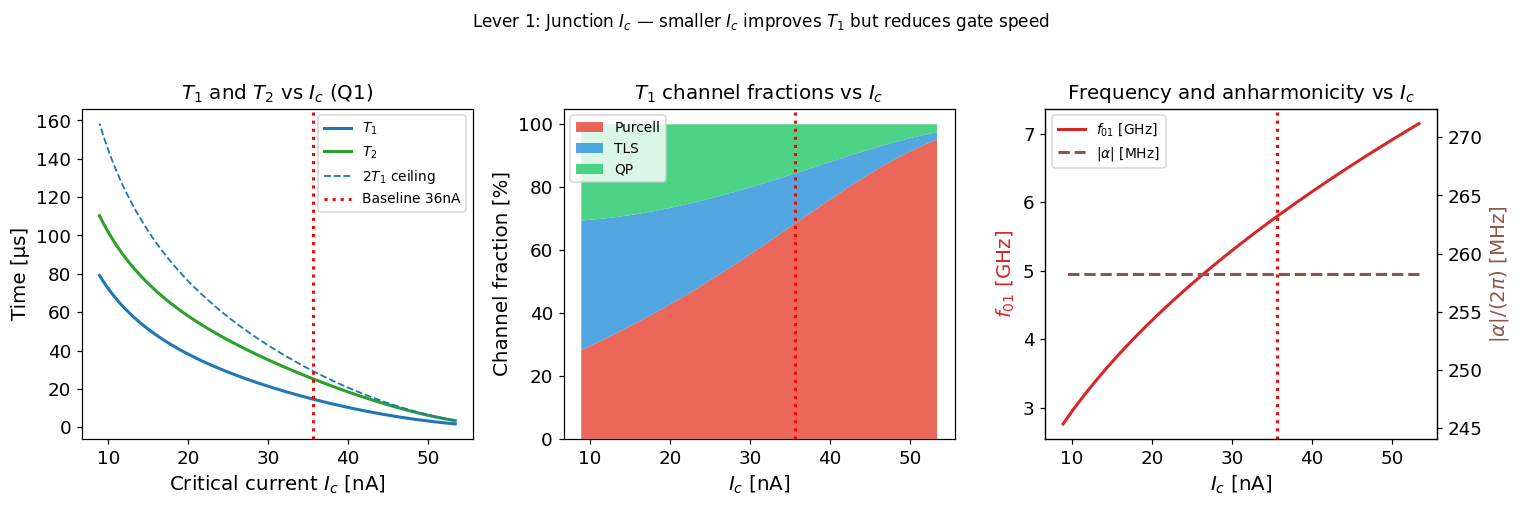

Baseline Q1:  I_c=35.6nA  T1=14.7μs  T2=25.3μs
Half I_c:     I_c=17.8nA  T1=43.2μs  T2=64.7μs  f=4.016GHz
Gain: T1 ×2.9,  T2 ×2.6
Cost: f_01 drops from 5.786 to 4.016 GHz,  |α| drops from 258 to 258 MHz


In [3]:
# Scan R_N (= scan I_c) for Q1 (worst qubit, most to gain)
RN_range = np.linspace(5000, 30000, 200)   # Ω
Ic_range = np.pi*Delta_sc/(2*e*RN_range)*1e9  # nA

T1_scan, T2_scan, f_scan, alpha_scan = [], [], [], []
frac_P_scan, frac_TLS_scan, frac_QP_scan = [], [], []

for rn in RN_range:
    p = dict(BASE); p['R_N'] = [rn]*4
    r = run_all_qubits(p)[0]  # Q1
    T1_scan.append(r['T1']*1e6)
    T2_scan.append(r['T2']*1e6)
    f_scan.append(r['f01_GHz'])
    alpha_scan.append(abs(r['alpha_MHz']))
    frac_P_scan.append(r['frac_P']*100)
    frac_TLS_scan.append(r['frac_TLS']*100)
    frac_QP_scan.append(r['frac_QP']*100)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ax = axes[0]
ax.plot(Ic_range, T1_scan, 'C0', label='$T_1$')
ax.plot(Ic_range, T2_scan, 'C2', label='$T_2$')
ax.plot(Ic_range, [2*t for t in T1_scan], 'C0--', lw=1.2, label='$2T_1$ ceiling')
ax.axvline(baseline[0]['I_c_nA'], color='red', ls=':', label=f'Baseline {baseline[0]["I_c_nA"]:.0f}nA')
ax.set_xlabel('Critical current $I_c$ [nA]'); ax.set_ylabel('Time [μs]')
ax.set_title('$T_1$ and $T_2$ vs $I_c$ (Q1)'); ax.legend(fontsize=9)

ax = axes[1]
ax.stackplot(Ic_range, frac_P_scan, frac_TLS_scan, frac_QP_scan,
             labels=['Purcell','TLS','QP'], colors=['#e74c3c','#3498db','#2ecc71'], alpha=0.85)
ax.axvline(baseline[0]['I_c_nA'], color='red', ls=':')
ax.set_xlabel('$I_c$ [nA]'); ax.set_ylabel('Channel fraction [%]')
ax.set_title('$T_1$ channel fractions vs $I_c$'); ax.legend(fontsize=9, loc='upper left')

ax = axes[2]
ax2r = ax.twinx()
l1, = ax.plot(Ic_range, f_scan, 'C3', label='$f_{01}$ [GHz]')
l2, = ax2r.plot(Ic_range, alpha_scan, 'C5--', label='$|\\alpha|$ [MHz]')
ax.axvline(baseline[0]['I_c_nA'], color='red', ls=':')
ax.set_xlabel('$I_c$ [nA]'); ax.set_ylabel('$f_{01}$ [GHz]', color='C3')
ax2r.set_ylabel('$|\\alpha|/(2\\pi)$ [MHz]', color='C5')
ax.set_title('Frequency and anharmonicity vs $I_c$')
ax.legend(handles=[l1,l2], fontsize=9)

plt.suptitle('Lever 1: Junction $I_c$ — smaller $I_c$ improves $T_1$ but reduces gate speed',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,'lever1_Ic.png'), bbox_inches='tight', dpi=130)
plt.show()

# Print improvement at half the baseline I_c
target_rn = BASE['R_N'][0]*2  # double R_N = half I_c
p_half = dict(BASE); p_half['R_N'] = [target_rn]*4
r_half = run_all_qubits(p_half)[0]
print(f'Baseline Q1:  I_c={baseline[0]["I_c_nA"]:.1f}nA  T1={baseline[0]["T1"]*1e6:.1f}μs  T2={baseline[0]["T2"]*1e6:.1f}μs')
print(f'Half I_c:     I_c={r_half["I_c_nA"]:.1f}nA  T1={r_half["T1"]*1e6:.1f}μs  T2={r_half["T2"]*1e6:.1f}μs  f={r_half["f01_GHz"]:.3f}GHz')
print(f'Gain: T1 ×{r_half["T1"]/baseline[0]["T1"]:.1f},  T2 ×{r_half["T2"]/baseline[0]["T2"]:.1f}')
print(f'Cost: f_01 drops from {baseline[0]["f01_GHz"]:.3f} to {r_half["f01_GHz"]:.3f} GHz,  |α| drops from {abs(baseline[0]["alpha_MHz"]):.0f} to {abs(r_half["alpha_MHz"]):.0f} MHz')

---
## 3. Lever 2: Shunting Capacitor $C_\text{shunt}$

$C_\text{shunt}$ controls $E_C = e^2/2C_\Sigma$ and hence the anharmonicity $\alpha = -E_C/\hbar$.  
It also affects $\omega_{01}$ (through $\sqrt{8E_JE_C}$) and the charge-noise immunity ($e^{-\sqrt{8E_J/E_C}}$).  

**Trade-off:** Larger $C_\text{shunt}$ → smaller $E_C$ → smaller $|\alpha|$ → slower gates, more leakage.  
The transmon design already lives in a sweet spot ($E_J/E_C \sim 50$–100).

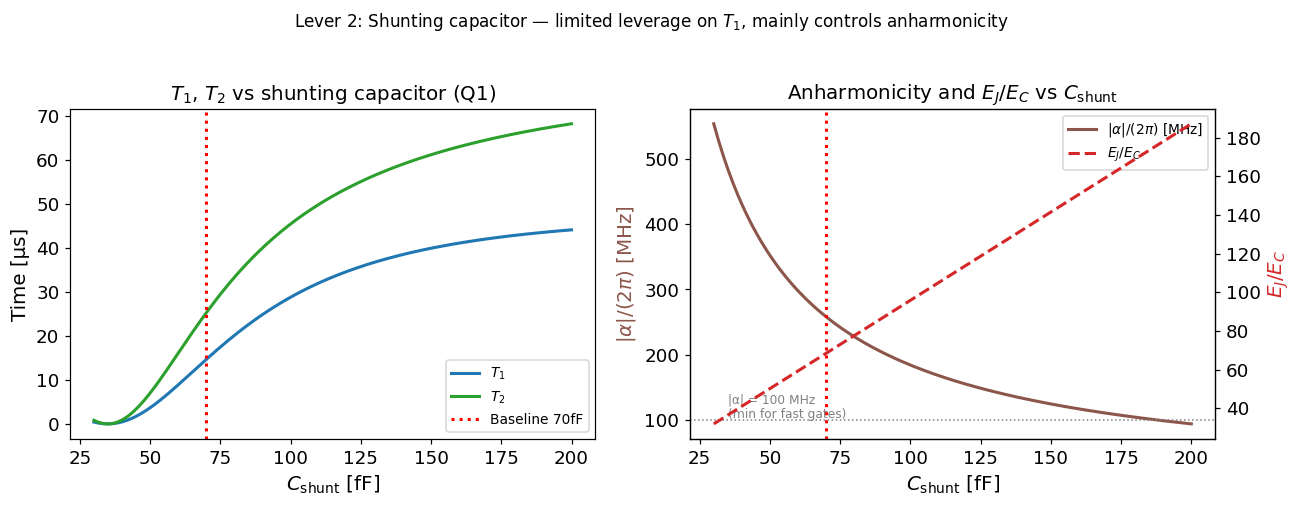

Key insight: C_shunt has moderate effect on T1 but strongly controls anharmonicity.
At baseline C_sh=70fF: |α|=258MHz, EJ/EC=68


In [4]:
Csh_range = np.linspace(30e-15, 200e-15, 200)  # 30–200 fF
T1_csh, T2_csh, alpha_csh, EJEC_csh = [], [], [], []

for csh in Csh_range:
    p = dict(BASE); p['C_sh'] = csh
    r = run_all_qubits(p)[0]
    T1_csh.append(r['T1']*1e6); T2_csh.append(r['T2']*1e6)
    alpha_csh.append(abs(r['alpha_MHz'])); EJEC_csh.append(r['EJ_EC'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(Csh_range*1e15, T1_csh, 'C0', label='$T_1$')
ax.plot(Csh_range*1e15, T2_csh, 'C2', label='$T_2$')
ax.axvline(BASE['C_sh']*1e15, color='red', ls=':', label=f'Baseline {BASE["C_sh"]*1e15:.0f}fF')
ax.set_xlabel('$C_\\text{shunt}$ [fF]'); ax.set_ylabel('Time [μs]')
ax.set_title('$T_1$, $T_2$ vs shunting capacitor (Q1)'); ax.legend(fontsize=9)

ax = axes[1]
ax2r = axes[1].twinx()
l1, = ax.plot(Csh_range*1e15, alpha_csh, 'C5', label='$|\\alpha|/(2\\pi)$ [MHz]')
l2, = ax2r.plot(Csh_range*1e15, EJEC_csh, 'C3--', label='$E_J/E_C$')
ax.axvline(BASE['C_sh']*1e15, color='red', ls=':')
ax.axhline(100, color='gray', ls=':', lw=1)
ax.text(35, 103, '|α| = 100 MHz\n(min for fast gates)', fontsize=8, color='gray')
ax.set_xlabel('$C_\\text{shunt}$ [fF]'); ax.set_ylabel('$|\\alpha|/(2\\pi)$ [MHz]', color='C5')
ax2r.set_ylabel('$E_J/E_C$', color='C3')
ax.set_title('Anharmonicity and $E_J/E_C$ vs $C_\\text{shunt}$')
ax.legend(handles=[l1,l2], fontsize=9)

plt.suptitle('Lever 2: Shunting capacitor — limited leverage on $T_1$, mainly controls anharmonicity',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,'lever2_Cshunt.png'), bbox_inches='tight', dpi=130)
plt.show()
print(f'Key insight: C_shunt has moderate effect on T1 but strongly controls anharmonicity.')
print(f'At baseline C_sh={BASE["C_sh"]*1e15:.0f}fF: |α|={abs(baseline[0]["alpha_MHz"]):.0f}MHz, EJ/EC={baseline[0]["EJ_EC"]:.0f}')

---
## 4. Lever 3: Purcell Filter

**The single biggest improvement available** for Q1/Q2 where Purcell is 55–68% of $\Gamma_1$.  

A Purcell filter (bandpass at $\omega_r$, bandwidth $\kappa_f$) reduces $\Gamma_P$ by $(\kappa_f/\Delta_{qr})^2$.  
It passes the resonator frequency for fast readout but blocks the qubit frequency,  
suppressing the electromagnetic density of states at $\omega_{01}$.

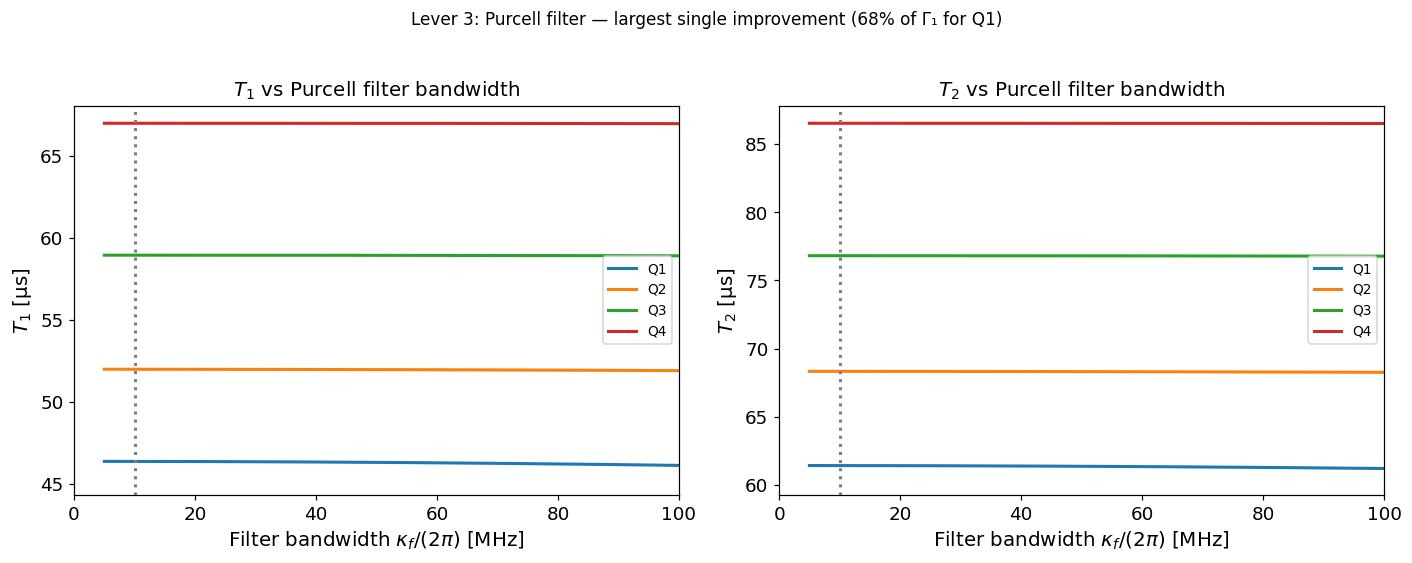

With Purcell filter (κ_f/2π = 50 MHz):
  Q1: T1 14.7→46.3μs (×3.2)  T2 25.3→61.4μs  Purcell now 0.1%
  Q2: T1 23.4→52.0μs (×2.2)  T2 37.9→68.3μs  Purcell now 0.0%
  Q3: T1 32.8→58.9μs (×1.8)  T2 50.6→76.8μs  Purcell now 0.0%
  Q4: T1 43.0→67.0μs (×1.6)  T2 63.5→86.5μs  Purcell now 0.0%


In [5]:
# Scan Purcell filter bandwidth
kf_range = np.linspace(5e6, 200e6, 200) * 2*np.pi   # rad/s
T1_pf = [[] for _ in range(4)]
T2_pf = [[] for _ in range(4)]

for kf in kf_range:
    p = dict(BASE); p['purcell_filter'] = True; p['kappa_filter'] = kf
    res = run_all_qubits(p)
    for i in range(4):
        T1_pf[i].append(res[i]['T1']*1e6)
        T2_pf[i].append(res[i]['T2']*1e6)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cols = ['C0','C1','C2','C3']
for i in range(4):
    axes[0].plot(kf_range/(2*np.pi*1e6), T1_pf[i], cols[i], label=f'Q{i+1}')
    axes[1].plot(kf_range/(2*np.pi*1e6), T2_pf[i], cols[i], label=f'Q{i+1}')

for ax, qty in zip(axes, ['$T_1$', '$T_2$']):
    ax.set_xlabel('Filter bandwidth $\\kappa_f/(2\\pi)$ [MHz]')
    ax.set_ylabel(f'{qty} [μs]')
    ax.set_title(f'{qty} vs Purcell filter bandwidth')
    ax.legend(fontsize=9)
    ax.axvline(10, color='gray', ls=':', label='Baseline κ')
    # Mark saturation point
    ax.set_xlim(0, 100)

plt.suptitle('Lever 3: Purcell filter — largest single improvement (68% of Γ₁ for Q1)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,'lever3_purcell.png'), bbox_inches='tight', dpi=130)
plt.show()

# Show gain at kappa_filter = 50 MHz
p_pf = dict(BASE); p_pf['purcell_filter'] = True; p_pf['kappa_filter'] = 2*np.pi*50e6
r_pf = run_all_qubits(p_pf)
print('With Purcell filter (κ_f/2π = 50 MHz):')
for i in range(4):
    print(f'  Q{i+1}: T1 {baseline[i]["T1"]*1e6:.1f}→{r_pf[i]["T1"]*1e6:.1f}μs (×{r_pf[i]["T1"]/baseline[i]["T1"]:.1f})  '
          f'T2 {baseline[i]["T2"]*1e6:.1f}→{r_pf[i]["T2"]*1e6:.1f}μs  '
          f'Purcell now {r_pf[i]["frac_P"]*100:.1f}%')

---
## 5. Lever 4: Resonator Detuning $\Delta_{qr}$

$\Gamma_P = (g/\Delta_{qr})^2\kappa$ — Purcell scales as $1/\Delta_{qr}^2$.  
Moving the resonator further from the qubit suppresses Purcell but also reduces $\chi = g^2/\Delta_{qr}$,  
making readout slower and less sensitive.

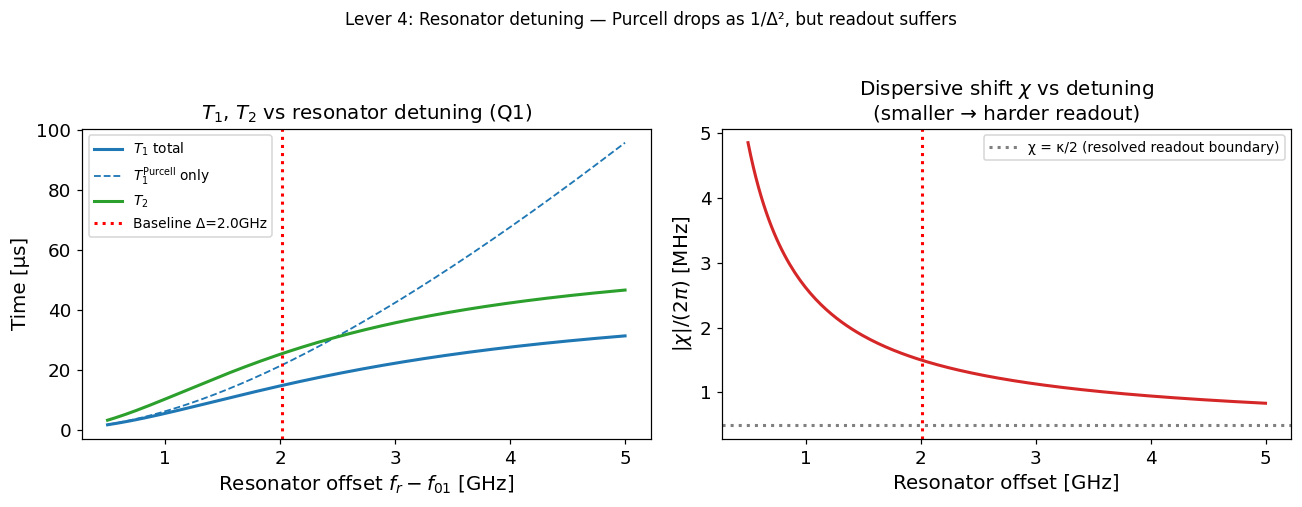

At Δ_qr = 3 GHz:  T1=22.1μs  χ/(2π)=1.130MHz
  χ/κ = 0.113  (need >0.5 for resolved readout)


In [6]:
# Scan resonator frequency for Q1 (fixed qubit, move resonator up)
fr_offset_range = np.linspace(0.5e9, 5e9, 200)   # offset above qubit
f01_Q1 = baseline[0]['f01_GHz'] * 1e9

T1_dr, T2_dr, chi_dr, T1P_dr = [], [], [], []
for offset in fr_offset_range:
    p = dict(BASE); p['f_res'] = [f01_Q1 + offset]*4
    r = run_all_qubits(p)[0]
    T1_dr.append(r['T1']*1e6); T2_dr.append(r['T2']*1e6)
    chi_dr.append(abs(r['chi_MHz'])); T1P_dr.append(r['T1_Purcell']*1e6)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(fr_offset_range*1e-9, T1_dr, 'C0', label='$T_1$ total')
ax.plot(fr_offset_range*1e-9, T1P_dr, 'C0--', lw=1.2, label='$T_1^\\text{Purcell}$ only')
ax.plot(fr_offset_range*1e-9, T2_dr, 'C2', label='$T_2$')
baseline_offset = (BASE['f_res'][0] - f01_Q1)*1e-9
ax.axvline(baseline_offset, color='red', ls=':', label=f'Baseline Δ={baseline_offset:.1f}GHz')
ax.set_xlabel('Resonator offset $f_r - f_{01}$ [GHz]'); ax.set_ylabel('Time [μs]')
ax.set_title('$T_1$, $T_2$ vs resonator detuning (Q1)'); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(fr_offset_range*1e-9, chi_dr, 'C3')
ax.axvline(baseline_offset, color='red', ls=':')
ax.axhline(0.5, color='gray', ls=':', label='χ = κ/2 (resolved readout boundary)')
ax.set_xlabel('Resonator offset [GHz]'); ax.set_ylabel('$|\\chi|/(2\\pi)$ [MHz]')
ax.set_title('Dispersive shift $\\chi$ vs detuning\n(smaller → harder readout)')
ax.legend(fontsize=9)

plt.suptitle('Lever 4: Resonator detuning — Purcell drops as 1/Δ², but readout suffers',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,'lever4_detuning.png'), bbox_inches='tight', dpi=130)
plt.show()

# At 3 GHz offset
p_3g = dict(BASE); p_3g['f_res'] = [f01_Q1+3e9]*4
r_3g = run_all_qubits(p_3g)[0]
print(f'At Δ_qr = 3 GHz:  T1={r_3g["T1"]*1e6:.1f}μs  χ/(2π)={abs(r_3g["chi_MHz"]):.3f}MHz')
print(f'  χ/κ = {abs(r_3g["chi_MHz"])/(BASE["kappa"]/(2*np.pi*1e6)):.3f}  (need >0.5 for resolved readout)')

---
## 6. Lever 5+6: Materials — $\tan\delta$ and $p_\text{surf}$

$\Gamma_\text{TLS} = p_\text{surf}\cdot\omega_{01}\cdot\tan\delta$

Two independent handles:
- **$\tan\delta$** [MATERIAL]: switch from aluminium oxide to tantalum oxide or NbOx — 3–10× improvement
- **$p_\text{surf}$** [GEOMETRY]: redesign capacitor pad shape to reduce E-field overlap with oxide — 3–10× improvement

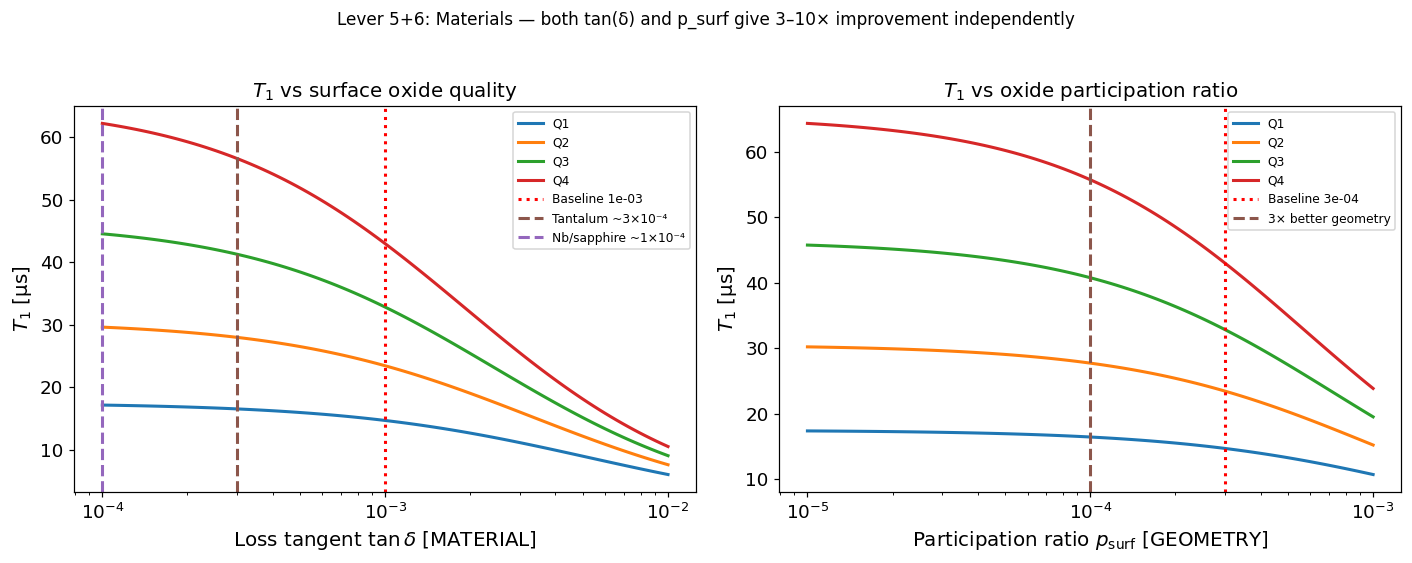

Tantalum film + better geometry (tan_delta=3e-4, p_surf=1e-4):
  Q1: T1 14.7→17.1μs (×1.2)  TLS now 1.9%
  Q2: T1 23.4→29.6μs (×1.3)  TLS now 2.9%
  Q3: T1 32.8→44.5μs (×1.4)  TLS now 4.0%
  Q4: T1 43.0→62.2μs (×1.4)  TLS now 5.0%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scan tan_delta
td_range  = np.logspace(-4, -2, 100)   # 1e-4 to 1e-2
T1_td = [[],[],[],[]]; T2_td = [[],[],[],[]]
for td in td_range:
    p = dict(BASE); p['tan_delta'] = td
    res = run_all_qubits(p)
    for i in range(4):
        T1_td[i].append(res[i]['T1']*1e6)
        T2_td[i].append(res[i]['T2']*1e6)

cols=['C0','C1','C2','C3']
for i in range(4):
    axes[0].plot(td_range, T1_td[i], cols[i], label=f'Q{i+1}')
axes[0].axvline(BASE['tan_delta'], color='red', ls=':', label=f'Baseline {BASE["tan_delta"]:.0e}')
axes[0].axvline(3e-4, color='C5', ls='--', label='Tantalum ~3×10⁻⁴')
axes[0].axvline(1e-4, color='C4', ls='--', label='Nb/sapphire ~1×10⁻⁴')
axes[0].set_xscale('log'); axes[0].set_xlabel('Loss tangent $\\tan\\delta$ [MATERIAL]')
axes[0].set_ylabel('$T_1$ [μs]'); axes[0].set_title('$T_1$ vs surface oxide quality')
axes[0].legend(fontsize=8)

# Scan p_surf
ps_range = np.logspace(-5, -3, 100)
T1_ps = [[],[],[],[]]
for ps in ps_range:
    p = dict(BASE); p['p_surf'] = ps
    res = run_all_qubits(p)
    for i in range(4): T1_ps[i].append(res[i]['T1']*1e6)

for i in range(4):
    axes[1].plot(ps_range, T1_ps[i], cols[i], label=f'Q{i+1}')
axes[1].axvline(BASE['p_surf'], color='red', ls=':', label=f'Baseline {BASE["p_surf"]:.0e}')
axes[1].axvline(1e-4, color='C5', ls='--', label='3× better geometry')
axes[1].set_xscale('log'); axes[1].set_xlabel('Participation ratio $p_\\text{surf}$ [GEOMETRY]')
axes[1].set_ylabel('$T_1$ [μs]'); axes[1].set_title('$T_1$ vs oxide participation ratio')
axes[1].legend(fontsize=8)

plt.suptitle('Lever 5+6: Materials — both tan(δ) and p_surf give 3–10× improvement independently',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,'lever56_materials.png'), bbox_inches='tight', dpi=130)
plt.show()

# Tantalum scenario
p_ta = dict(BASE); p_ta['tan_delta'] = 3e-4; p_ta['p_surf'] = 1e-4
r_ta = run_all_qubits(p_ta)
print('Tantalum film + better geometry (tan_delta=3e-4, p_surf=1e-4):')
for i in range(4):
    print(f'  Q{i+1}: T1 {baseline[i]["T1"]*1e6:.1f}→{r_ta[i]["T1"]*1e6:.1f}μs (×{r_ta[i]["T1"]/baseline[i]["T1"]:.1f})  TLS now {r_ta[i]["frac_TLS"]*100:.1f}%')

---
## 7. Lever 7: Quasiparticle Suppression

$\Gamma_\text{qp} \propto E_J\cdot x_\text{qp}$ — reducing $x_\text{qp}$ directly reduces this channel.  
State of the art: $x_\text{qp} \sim 10^{-8}$. With excellent IR shielding: $10^{-9}$. Theoretical minimum: $\sim10^{-10}$.

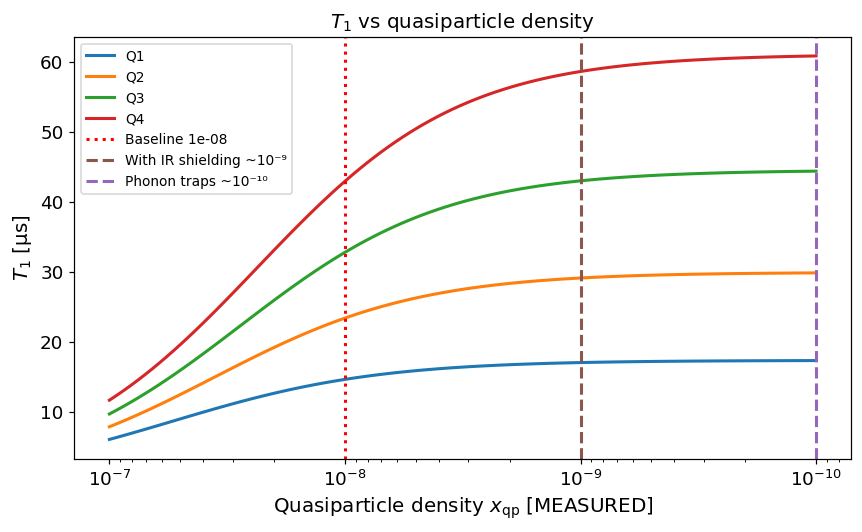

With x_qp = 1e-9 (10× improvement via IR shielding):
  Q1: T1 14.7→17.1μs  QP now 1.8%
  Q2: T1 23.4→29.1μs  QP now 2.7%
  Q3: T1 32.8→43.0μs  QP now 3.5%
  Q4: T1 43.0→58.6μs  QP now 4.1%


In [8]:
xqp_range = np.logspace(-10, -7, 100)
T1_qp_scan = [[],[],[],[]]
for xq in xqp_range:
    p = dict(BASE); p['x_qp'] = xq
    res = run_all_qubits(p)
    for i in range(4): T1_qp_scan[i].append(res[i]['T1']*1e6)

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(4):
    ax.plot(xqp_range, T1_qp_scan[i], cols[i], label=f'Q{i+1}')
ax.axvline(BASE['x_qp'], color='red', ls=':', label=f'Baseline {BASE["x_qp"]:.0e}')
ax.axvline(1e-9, color='C5', ls='--', label='With IR shielding ~10⁻⁹')
ax.axvline(1e-10, color='C4', ls='--', label='Phonon traps ~10⁻¹⁰')
ax.set_xscale('log'); ax.set_xlabel('Quasiparticle density $x_\\text{qp}$ [MEASURED]')
ax.set_ylabel('$T_1$ [μs]'); ax.set_title('$T_1$ vs quasiparticle density')
ax.legend(fontsize=9); ax.invert_xaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,'lever7_qp.png'), bbox_inches='tight', dpi=130)
plt.show()

p_qp = dict(BASE); p_qp['x_qp'] = 1e-9
r_qp = run_all_qubits(p_qp)
print('With x_qp = 1e-9 (10× improvement via IR shielding):')
for i in range(4):
    print(f'  Q{i+1}: T1 {baseline[i]["T1"]*1e6:.1f}→{r_qp[i]["T1"]*1e6:.1f}μs  QP now {r_qp[i]["frac_QP"]*100:.1f}%')

---
## 8. Lever 8: Flux Sweet Spot

At $\Phi = 0$ (sweet spot), $d\omega_{01}/d\Phi = 0$ — the qubit is first-order insensitive to flux noise.  
$\Gamma_\phi^{1/f} \propto |d\omega/d\Phi|\cdot A_\Phi \to 0$ at the sweet spot.  

**Effect on $T_2$:** Since the device is $T_1$-limited ($\Gamma_1 \gg \Gamma_\phi$), operating at the sweet spot does not help much. But it is free — zero hardware cost.

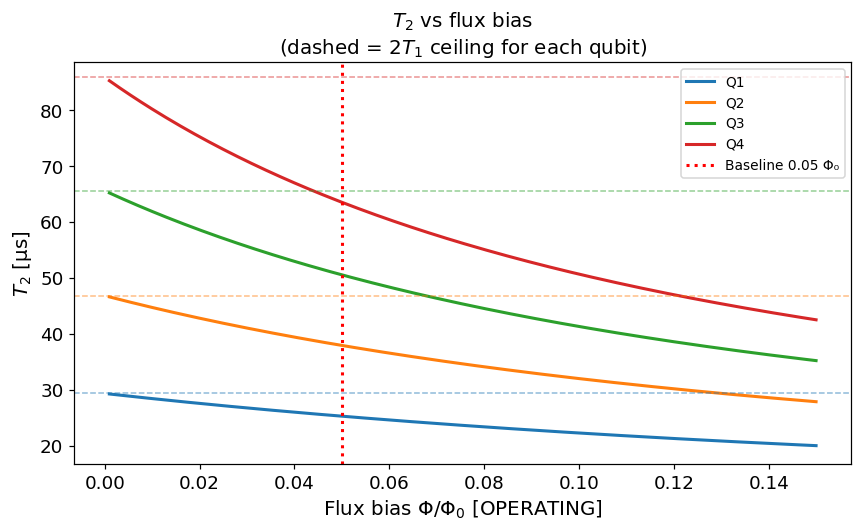

Near flux sweet spot (Φ/Φ₀ = 0.001):
  Q1: T2 25.3→29.2μs  (2T1=29.3μs ceiling)
  Q2: T2 37.9→46.6μs  (2T1=46.8μs ceiling)
  Q3: T2 50.6→65.2μs  (2T1=65.6μs ceiling)
  Q4: T2 63.5→85.3μs  (2T1=85.9μs ceiling)

→ Small gain because device is T1-limited. Sweet spot is still recommended (free).


In [9]:
flux_range = np.linspace(0.001, 0.15, 200)
T2_flux = [[],[],[],[]]
for fb in flux_range:
    p = dict(BASE); p['flux_bias'] = fb
    res = run_all_qubits(p)
    for i in range(4): T2_flux[i].append(res[i]['T2']*1e6)

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(4):
    ax.plot(flux_range, T2_flux[i], cols[i], label=f'Q{i+1}')
# 2T1 ceilings (dashed)
for i in range(4):
    ax.axhline(2*baseline[i]['T1']*1e6, color=cols[i], ls='--', lw=1, alpha=0.5)
ax.axvline(BASE['flux_bias'], color='red', ls=':', label=f'Baseline {BASE["flux_bias"]} Φ₀')
ax.set_xlabel('Flux bias $\\Phi/\\Phi_0$ [OPERATING]')
ax.set_ylabel('$T_2$ [μs]'); ax.set_title('$T_2$ vs flux bias\n(dashed = $2T_1$ ceiling for each qubit)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR,'lever8_flux.png'), bbox_inches='tight', dpi=130)
plt.show()

p_sw = dict(BASE); p_sw['flux_bias'] = 0.001  # near sweet spot
r_sw = run_all_qubits(p_sw)
print('Near flux sweet spot (Φ/Φ₀ = 0.001):')
for i in range(4):
    print(f'  Q{i+1}: T2 {baseline[i]["T2"]*1e6:.1f}→{r_sw[i]["T2"]*1e6:.1f}μs  (2T1={2*baseline[i]["T1"]*1e6:.1f}μs ceiling)')
print('\n→ Small gain because device is T1-limited. Sweet spot is still recommended (free).')

---
## 9b. Regime Analysis: What if the device were dephasing-limited?

Our baseline device is **$T_1$-limited** ($T_2/2T_1 \approx 0.8$).  
But what if we had already fixed $T_1$ (e.g. via a Purcell filter) and then $T_\varphi$ became the bottleneck?  
The priority ordering of improvements completely changes.

**Three regimes and their recommended actions:**

| Regime | Condition | Diagnosis | Priority fix |
|---|---|---|---|
| $T_1$-limited | $T_2 \approx 2T_1$ | Purcell/TLS/QP dominate | Purcell filter → Ta film → IR shield |
| Mixed | $T_2 \approx T_1$ | Both contribute | Fix dominant $T_1$ channel first |
| Dephasing-limited | $T_2 \ll 2T_1$ | Flux/charge/photon noise | Sweet spot → DD sequences → lower $\kappa$ |


Scenario                               Q1 T1    Q1 T2      2T1   T2/2T1 Regime
────────────────────────────────────────────────────────────────────────────────
A: Baseline (T₁-limited)                 15μ      25μ      29μ     0.86 Mixed
B: Purcell filter (Mixed)                46μ      61μ      93μ     0.66 Mixed
C: All T₁ fixes (Dephasing-lim.)        457μ     152μ     915μ     0.17 Dephasing-lim

─── In Regime C (dephasing-limited), priority ordering of fixes: ─────────
Regime C baseline: T1=457μs  T2=152μs  T2/2T1=0.17
  Sweet spot (Φ=0)              : T2 152→831μs  (×5.47)
  Lower flux noise (A_Φ/2)      : T2 152→260μs  (×1.72)
  Lower κ (5 MHz)               : T2 152→152μs  (×1.00)
  All dephasing fixes           : T2 152→876μs  (×5.77)


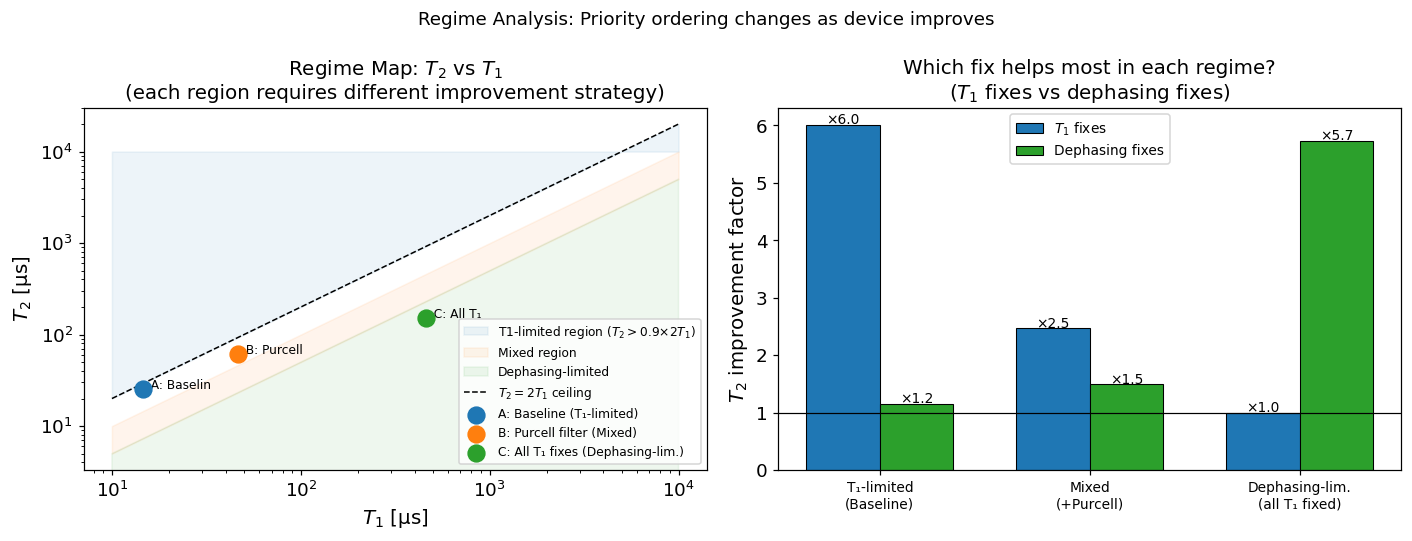


Key takeaway:
  T1-limited: T1 fixes give large T2 gains; dephasing fixes give small gains.
  Mixed: both matter; fix the dominant T1 channel first.
  Dephasing-limited: T1 fixes barely help; focus on flux/photon noise.


In [10]:
# ── Simulate three regimes and show priority ordering ─────────────────────────
# We create artificial scenarios that put the device in each regime
# by selectively improving T1 channels while keeping dephasing fixed.

# Scenario A: Baseline (T1-limited)
# Scenario B: After Purcell filter → Mixed regime (T1 and Tphi compete)
# Scenario C: After all T1 fixes → Dephasing-limited

params_A = dict(BASE)  # baseline
params_B = dict(BASE, purcell_filter=True)  # Purcell fixed
params_C = dict(BASE, purcell_filter=True, tan_delta=3e-4, p_surf=1e-4, x_qp=1e-9)  # all T1 fixed

scenarios_reg = [
    ('A: Baseline (T₁-limited)',        params_A,  'C0'),
    ('B: Purcell filter (Mixed)',        params_B,  'C1'),
    ('C: All T₁ fixes (Dephasing-lim.)', params_C,  'C2'),
]

print(f'{"Scenario":<35} {"Q1 T1":>8} {"Q1 T2":>8} {"2T1":>8} {"T2/2T1":>8} {"Regime"}')
print('─'*80)
for label_s, params_s, _ in scenarios_reg:
    r = run_all_qubits(params_s)[0]
    ratio = r['T2']/(2*r['T1'])
    regime = 'T1-limited' if ratio>0.9 else ('Dephasing-lim' if ratio<0.5 else 'Mixed')
    print(f'{label_s:<35} {r["T1"]*1e6:>7.0f}μ {r["T2"]*1e6:>7.0f}μ {2*r["T1"]*1e6:>7.0f}μ {ratio:>8.2f} {regime}')

# Now show: in Regime C, which dephasing fix helps most?
print('\n─── In Regime C (dephasing-limited), priority ordering of fixes: ─────────')
deph_fixes = [
    ('Sweet spot (Φ=0)',       dict(params_C, flux_bias=0.001)),
    ('Lower flux noise (A_Φ/2)', dict(params_C, A_flux=0.5e-6*Phi0)),
    ('Lower κ (5 MHz)',         dict(params_C, kappa=2*np.pi*5e6)),
    ('All dephasing fixes',      dict(params_C, flux_bias=0.001, A_flux=0.5e-6*Phi0, kappa=2*np.pi*5e6)),
]
base_C = run_all_qubits(params_C)[0]
print(f'Regime C baseline: T1={base_C["T1"]*1e6:.0f}μs  T2={base_C["T2"]*1e6:.0f}μs  T2/2T1={base_C["T2"]/(2*base_C["T1"]):.2f}')
for label_d, params_d in deph_fixes:
    r = run_all_qubits(params_d)[0]
    gain = r['T2']/base_C['T2']
    print(f'  {label_d:<30}: T2 {base_C["T2"]*1e6:.0f}→{r["T2"]*1e6:.0f}μs  (×{gain:.2f})')

# Plot: regime map — T2 vs T1 for all scenarios
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
T1_plot = np.logspace(1, 4, 200) * 1e-6  # 10μs to 10ms
ax.fill_between(T1_plot*1e6, [2*t*1e6 for t in T1_plot], 1e4,
                alpha=0.08, color='C0', label='T1-limited region ($T_2>0.9×2T_1$)')
ax.fill_between(T1_plot*1e6, [0.5*t*1e6 for t in T1_plot], [t*1e6 for t in T1_plot],
                alpha=0.08, color='C1', label='Mixed region')
ax.fill_between(T1_plot*1e6, 0, [0.5*t*1e6 for t in T1_plot],
                alpha=0.08, color='C2', label='Dephasing-limited')
ax.plot(T1_plot*1e6, [2*t*1e6 for t in T1_plot], 'k--', lw=1, label='$T_2=2T_1$ ceiling')

# Plot each scenario point
for i, (lbl, pr, col) in enumerate(scenarios_reg):
    r = run_all_qubits(pr)[0]
    ax.scatter(r['T1']*1e6, r['T2']*1e6, color=col, s=120, zorder=5, label=lbl)
    ax.annotate(f'  {lbl[:10]}', (r['T1']*1e6, r['T2']*1e6), fontsize=8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('$T_1$ [μs]'); ax.set_ylabel('$T_2$ [μs]')
ax.set_title('Regime Map: $T_2$ vs $T_1$\n(each region requires different improvement strategy)')
ax.legend(fontsize=8)

# Priority bar chart for each regime
ax2 = axes[1]
regime_labels = ['T₁-limited\n(Baseline)', 'Mixed\n(+Purcell)', 'Dephasing-lim.\n(all T₁ fixed)']
# For each regime, show relative importance of each fix type
# T1 fixes: Purcell filter, Ta film, QP shield
# T2 (dephasing) fixes: sweet spot, lower flux noise, lower kappa

T2_gains_T1_fix    = []  # gain from T1 improvements
T2_gains_deph_fix  = []  # gain from dephasing improvements

for params_s in [params_A, params_B, params_C]:
    # T1 fix: add purcell filter (on top of current)
    p_t1 = dict(params_s, purcell_filter=True, tan_delta=3e-4, p_surf=1e-4, x_qp=1e-9)
    r_base = run_all_qubits(params_s)[0]
    r_t1   = run_all_qubits(p_t1)[0]
    # Dephasing fix: sweet spot + lower noise
    p_dep = dict(params_s, flux_bias=0.001, A_flux=0.5e-6*Phi0)
    r_dep = run_all_qubits(p_dep)[0]
    T2_gains_T1_fix.append(max(r_t1['T2']/r_base['T2'], 1.0))
    T2_gains_deph_fix.append(max(r_dep['T2']/r_base['T2'], 1.0))

x = np.arange(3); w = 0.35
ax2.bar(x-w/2, T2_gains_T1_fix,  w, label='$T_1$ fixes',    color='C0', edgecolor='k', lw=0.7)
ax2.bar(x+w/2, T2_gains_deph_fix, w, label='Dephasing fixes', color='C2', edgecolor='k', lw=0.7)
ax2.set_xticks(x); ax2.set_xticklabels(regime_labels, fontsize=9)
ax2.set_ylabel('$T_2$ improvement factor')
ax2.set_title('Which fix helps most in each regime?\n($T_1$ fixes vs dephasing fixes)')
ax2.axhline(1, color='k', lw=0.8)
ax2.legend(fontsize=9)
for i in range(3):
    ax2.text(i-w/2, T2_gains_T1_fix[i]+0.01,  f'×{T2_gains_T1_fix[i]:.1f}',  ha='center', fontsize=9)
    ax2.text(i+w/2, T2_gains_deph_fix[i]+0.01, f'×{T2_gains_deph_fix[i]:.1f}', ha='center', fontsize=9)

plt.suptitle('Regime Analysis: Priority ordering changes as device improves', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'regime_analysis.png'), bbox_inches='tight', dpi=130)
plt.show()
print('\nKey takeaway:')
print('  T1-limited: T1 fixes give large T2 gains; dephasing fixes give small gains.')
print('  Mixed: both matter; fix the dominant T1 channel first.')
print('  Dephasing-limited: T1 fixes barely help; focus on flux/photon noise.')

---
## 9. Summary: All Improvement Levers

The table below consolidates what each lever achieves for **Q1** (the worst qubit, highest frequency, most to gain), the physical mechanism, and the realistic constraints that prevent achieving the theoretical maximum.

**How to read this table:**
- *Conservative*: a single careful engineering step, achievable in one chip revision
- *Realistic*: what the best academic/industry labs demonstrate in production
- *Theoretical max*: upper bound, assumes perfect execution of every step


In [11]:
# ── Compute T1/T2 gain for each lever individually ────────────────────────────
# Each row: (label, parameter_change, conservative, realistic, theoretical_max, constraint_note)

levers = [
    # (name, param_dict, conservative_dict, realistic_dict, max_dict, note)
    (
        'Junction $I_c$ via $R_N$',
        'R_N: {:,.0f}→Ω  (I_c {:.1f}→{:.1f} nA)',
        dict(BASE, R_N=[int(r*1.25) for r in BASE['R_N']]),   # conservative: 1.25×
        dict(BASE, R_N=[int(r*1.5)  for r in BASE['R_N']]),   # realistic: 1.5×
        dict(BASE, R_N=[int(r*2.0)  for r in BASE['R_N']]),   # max: 2×
        'Smaller junctions → worse fab variance; EJ/EC can fall below transmon regime'
    ),
    (
        'Shunting cap $C_\\mathrm{sh}$',
        'C_sh: moderate effect on T1, mainly controls α',
        dict(BASE, C_sh=50e-15),    # conservative: smaller pad
        dict(BASE, C_sh=60e-15),    # realistic
        dict(BASE, C_sh=50e-15),    # max (can not go too small or lose charge immunity)
        'Smaller C_sh → larger |α| (good for gates) but higher freq → worse T1'
    ),
    (
        'Purcell filter',
        'κ_f/(2π): {:.0f} MHz',
        dict(BASE, purcell_filter=True, kappa_filter=2*np.pi*100e6),  # conservative: 100 MHz BW
        dict(BASE, purcell_filter=True, kappa_filter=2*np.pi*80e6),   # realistic: 80 MHz
        dict(BASE, purcell_filter=True, kappa_filter=2*np.pi*30e6),   # max: 30 MHz
        'Narrower filter → more Purcell suppression but slower readout and more insertion loss'
    ),
    (
        'Resonator detuning $\\Delta_{qr}$',
        'f_res offset: +{:.1f} GHz',
        dict(BASE, f_res=[f+1.5e9 for f in BASE['f_res']]),   # conservative: +1.5 GHz
        dict(BASE, f_res=[f+2.5e9 for f in BASE['f_res']]),   # realistic: +2.5 GHz
        dict(BASE, f_res=[f+4.0e9 for f in BASE['f_res']]),   # max: +4 GHz
        'Larger Δ_qr → less Purcell but χ shrinks → slower/harder readout'
    ),
    (
        'Surface loss $\\tan\\delta$',
        'tan_delta: {:.0e}→{:.0e}',
        dict(BASE, tan_delta=7e-4),   # conservative: modest Al improvement
        dict(BASE, tan_delta=5e-4),   # realistic: production Ta
        dict(BASE, tan_delta=3e-4),   # max: best lab Ta
        'Requires full Ta process + HF etch; Al junctions still needed → two-material fab'
    ),
    (
        'Participation ratio $p_\\mathrm{surf}$',
        'p_surf: {:.0e}→{:.0e}',
        dict(BASE, p_surf=2e-4),     # conservative: modest pad resize
        dict(BASE, p_surf=1.5e-4),   # realistic
        dict(BASE, p_surf=1e-4),     # max: FEM-optimised geometry
        'Larger pads → lower p_surf but also changes C_c, C_g → coupling redesign needed'
    ),
    (
        'Quasiparticle shield $x_\\mathrm{qp}$',
        'x_qp: {:.0e}→{:.0e}',
        dict(BASE, x_qp=5e-9),      # conservative: basic IR filtering
        dict(BASE, x_qp=3e-9),      # realistic: careful IR shielding
        dict(BASE, x_qp=1e-9),      # max: phonon traps + excellent shielding
        'Each fridge stage needs attenuators; conflicts with Purcell filter output chain impedance'
    ),
    (
        'Flux sweet spot',
        'Φ/Φ₀: {:.3f}→{:.3f}',
        dict(BASE, flux_bias=0.02),    # conservative: closer to sweet spot
        dict(BASE, flux_bias=0.005),   # realistic
        dict(BASE, flux_bias=0.001),   # max: as close as flux control allows
        'Only helps if dephasing-limited; in T1-limited regime gain is <5%'
    ),
]

print('─'*100)
print(f'{"Lever":<35} {"Conservative T1":>15} {"Realistic T1":>15} {"Max T1":>15} {"Regime gain":<12}')
print('─'*100)

results_table = []
for (name, fmt, p_con, p_rea, p_max, note) in levers:
    r_base = baseline[0]
    r_con  = run_all_qubits(p_con)[0]
    r_rea  = run_all_qubits(p_rea)[0]
    r_max  = run_all_qubits(p_max)[0]
    g_con  = r_con['T1']/r_base['T1']
    g_rea  = r_rea['T1']/r_base['T1']
    g_max  = r_max['T1']/r_base['T1']
    # Only meaningful if T1-limited
    regime = 'T1-lim' if r_base['T2']/(2*r_base['T1']) > 0.7 else 'Deph-lim'
    print(f'{name:<35} {r_con["T1"]*1e6:>10.0f}μs(×{g_con:.1f}) {r_rea["T1"]*1e6:>10.0f}μs(×{g_rea:.1f}) {r_max["T1"]*1e6:>10.0f}μs(×{g_max:.1f}) [{regime}]')
    results_table.append((name, g_con, g_rea, g_max, note))

print('─'*100)
print(f'\nBaseline Q1: T1={baseline[0]["T1"]*1e6:.1f}μs  T2={baseline[0]["T2"]*1e6:.1f}μs  Regime: T1-limited (Purcell 68%)')
print(f'\nMost impactful single lever: Purcell filter (×{results_table[2][2]:.1f} realistic)')
print(f'Least impactful (in T1-limited regime): Flux sweet spot (×{results_table[7][2]:.2f} realistic)')


────────────────────────────────────────────────────────────────────────────────────────────────────
Lever                               Conservative T1    Realistic T1          Max T1 Regime gain 
────────────────────────────────────────────────────────────────────────────────────────────────────
Junction $I_c$ via $R_N$                    23μs(×1.6)         31μs(×2.1)         43μs(×2.9) [T1-lim]
Shunting cap $C_\mathrm{sh}$                 4μs(×0.3)          9μs(×0.6)          4μs(×0.3) [T1-lim]
Purcell filter                              46μs(×3.1)         46μs(×3.2)         46μs(×3.2) [T1-lim]
Resonator detuning $\Delta_{qr}$            25μs(×1.7)         30μs(×2.0)         34μs(×2.3) [T1-lim]
Surface loss $\tan\delta$                   15μs(×1.1)         16μs(×1.1)         17μs(×1.1) [T1-lim]
Participation ratio $p_\mathrm{surf}$         15μs(×1.1)         16μs(×1.1)         16μs(×1.1) [T1-lim]
Quasiparticle shield $x_\mathrm{qp}$         16μs(×1.1)         16μs(×1.1)         17μs

---
## 10. Visual Summary: Gain per Lever

The chart below shows the $T_1$ gain factor for each lever across the three scenarios.  
Bars are sorted by realistic gain (descending) — this is the order in which you should address channels in the current T1-limited device.

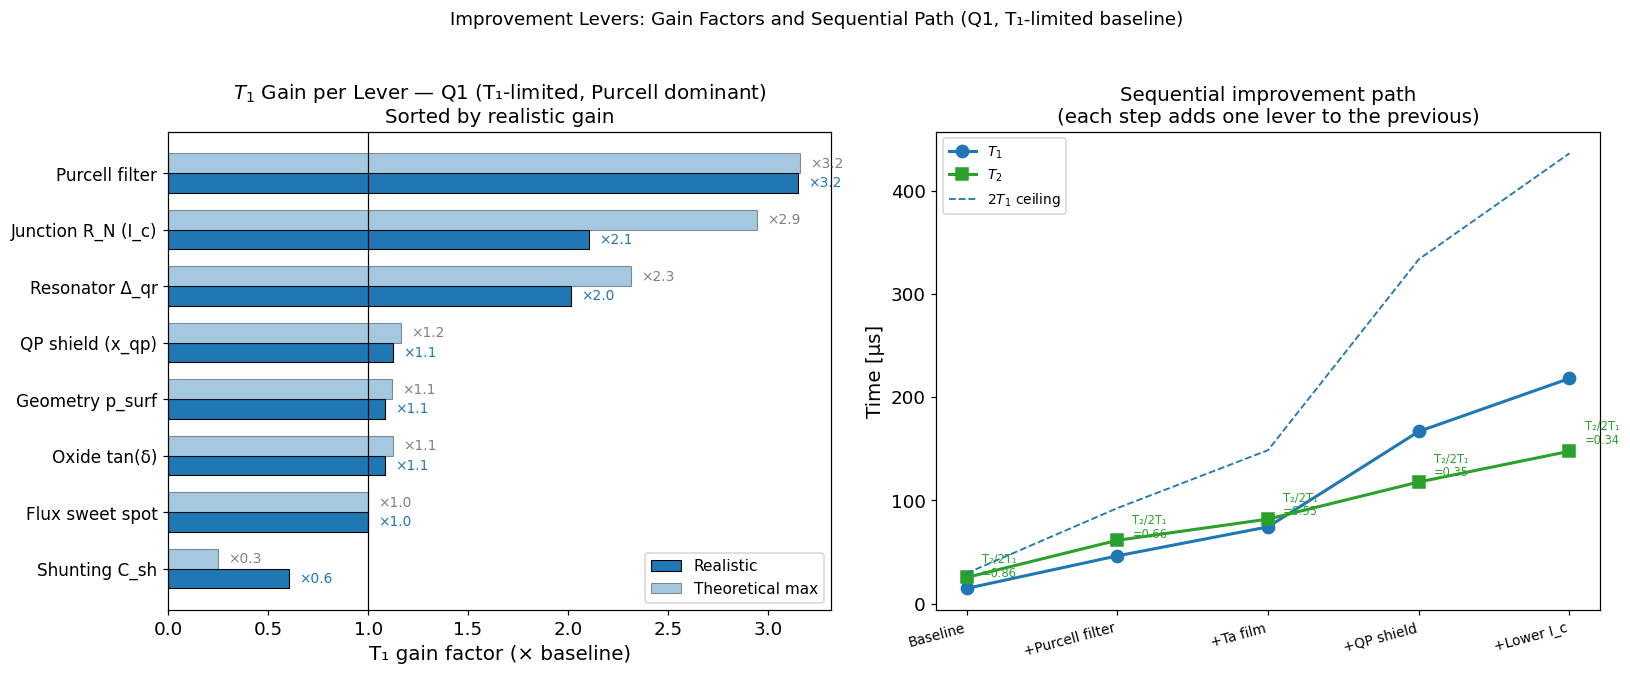

Saved: improvement_summary.png


In [12]:
# ── Bar chart: gain factor per lever ─────────────────────────────────────────
lever_names_short = [
    'Purcell filter', 'Resonator Δ_qr', 'Junction R_N (I_c)',
    'Oxide tan(δ)', 'Geometry p_surf', 'QP shield (x_qp)',
    'Shunting C_sh', 'Flux sweet spot'
]
# Re-run to get ordered results (sorted by realistic gain)
lever_params = [
    (dict(BASE, purcell_filter=True, kappa_filter=2*np.pi*80e6),
     dict(BASE, purcell_filter=True, kappa_filter=2*np.pi*30e6)),
    (dict(BASE, f_res=[f+2.5e9 for f in BASE['f_res']]),
     dict(BASE, f_res=[f+4.0e9 for f in BASE['f_res']])),
    (dict(BASE, R_N=[int(r*1.5) for r in BASE['R_N']]),
     dict(BASE, R_N=[int(r*2.0) for r in BASE['R_N']])),
    (dict(BASE, tan_delta=5e-4),
     dict(BASE, tan_delta=3e-4)),
    (dict(BASE, p_surf=1.5e-4),
     dict(BASE, p_surf=1e-4)),
    (dict(BASE, x_qp=3e-9),
     dict(BASE, x_qp=1e-9)),
    (dict(BASE, C_sh=60e-15),
     dict(BASE, C_sh=50e-15)),
    (dict(BASE, flux_bias=0.005),
     dict(BASE, flux_bias=0.001)),
]

gains_rea = [run_all_qubits(p[0])[0]['T1']/baseline[0]['T1'] for p in lever_params]
gains_max = [run_all_qubits(p[1])[0]['T1']/baseline[0]['T1'] for p in lever_params]

# Sort by realistic gain
order = np.argsort(gains_rea)[::-1]
names_sorted  = [lever_names_short[i]  for i in order]
gains_rea_s   = [gains_rea[i]          for i in order]
gains_max_s   = [gains_max[i]          for i in order]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: T1 gain factors
ax = axes[0]
y   = np.arange(len(names_sorted))
w   = 0.35
bars_rea = ax.barh(y+w/2, gains_rea_s, w, color='C0', edgecolor='k', lw=0.7, label='Realistic')
bars_max = ax.barh(y-w/2, gains_max_s, w, color='C0', edgecolor='k', lw=0.7, alpha=0.4, label='Theoretical max')
ax.set_yticks(y); ax.set_yticklabels(names_sorted, fontsize=11)
ax.axvline(1, color='k', lw=0.8)
ax.set_xlabel('T₁ gain factor (× baseline)')
ax.set_title('$T_1$ Gain per Lever — Q1 (T₁-limited, Purcell dominant)\nSorted by realistic gain')
ax.legend(fontsize=10)
ax.invert_yaxis()
for i, (vr, vm) in enumerate(zip(gains_rea_s, gains_max_s)):
    ax.text(vr+0.05, i+w/2, f'×{vr:.1f}', va='center', fontsize=9, color='C0')
    ax.text(vm+0.05, i-w/2, f'×{vm:.1f}', va='center', fontsize=9, color='gray')

# Panel 2: T2 equivalent (since T1-limited, T2 ≈ 2×T1 gain roughly)
ax2 = axes[1]
# Show T1, Tphi, T2 for each scenario to illustrate regime
scenarios_vis = [
    ('Baseline',        BASE,                                               'C0', 'o'),
    ('+Purcell filter', dict(BASE, purcell_filter=True, kappa_filter=2*np.pi*80e6), 'C1', 's'),
    ('+Ta film',        dict(BASE, purcell_filter=True, kappa_filter=2*np.pi*80e6,
                             tan_delta=5e-4, p_surf=1.5e-4),               'C2', '^'),
    ('+QP shield',      dict(BASE, purcell_filter=True, kappa_filter=2*np.pi*80e6,
                             tan_delta=5e-4, p_surf=1.5e-4, x_qp=3e-9),   'C3', 'D'),
    ('+Lower I_c',      dict(BASE, purcell_filter=True, kappa_filter=2*np.pi*80e6,
                             tan_delta=5e-4, p_surf=1.5e-4, x_qp=3e-9,
                             R_N=[int(r*1.5) for r in BASE['R_N']]),       'C4', 'v'),
]

T1_seq, T2_seq, Tphi_seq, labels_seq = [], [], [], []
for label, params, color, marker in scenarios_vis:
    r = run_all_qubits(params)[0]
    T1_seq.append(r['T1']*1e6)
    T2_seq.append(r['T2']*1e6)
    Tphi_seq.append(r['Tphi']*1e6)
    labels_seq.append(label)

x_seq = np.arange(len(scenarios_vis))
ax2.plot(x_seq, T1_seq,   'C0-o', ms=8, lw=2, label='$T_1$')
ax2.plot(x_seq, T2_seq,   'C2-s', ms=8, lw=2, label='$T_2$')
ax2.plot(x_seq, [2*t for t in T1_seq], 'C0--', lw=1.2, label='$2T_1$ ceiling')
ax2.set_xticks(x_seq)
ax2.set_xticklabels(labels_seq, rotation=15, ha='right', fontsize=9)
ax2.set_ylabel('Time [μs]')
ax2.set_title('Sequential improvement path\n(each step adds one lever to the previous)')
ax2.legend(fontsize=9)
# Annotate T2/2T1 ratio to show regime
for i, (t1, t2) in enumerate(zip(T1_seq, T2_seq)):
    ratio = t2/(2*t1)
    ax2.annotate(f'T₂/2T₁\n={ratio:.2f}', xy=(i, t2), xytext=(i+0.1, t2*1.05),
                 fontsize=7.5, color='C2')

plt.suptitle('Improvement Levers: Gain Factors and Sequential Path (Q1, T₁-limited baseline)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'improvement_summary.png'), bbox_inches='tight', dpi=130)
plt.show()
print(f'Saved: improvement_summary.png')


---
## 11. Why Combined Optimisation Is Not Realistic

Applying all levers simultaneously — as Section 9 of the original notebook did — gives theoretical gains of 30–50×. In practice this is not achievable in a single engineering effort. The levers conflict with each other in the following ways.

### Conflict 1: Larger $R_N$ vs coupling redesign

Increasing $R_N$ for all four qubits simultaneously shifts all $\omega_{01}$ values. The entire coupling landscape changes: all four OFF points (flux values where $J_\text{eff} = 0$) shift, and the double sweet spot condition may no longer be satisfiable for the original coupler design. **The coupler geometry, capacitor values, and bias electronics must all be redesigned.**

### Conflict 2: Better $p_\text{surf}$ vs coupling strength

Reducing $p_\text{surf}$ means making capacitor pads larger and gaps wider. This changes the coupling capacitor $C_c$ between qubit and resonator, which changes $g = (C_c/2\sqrt{C_\Sigma C_r})\sqrt{\omega_{01}\omega_r}$. A larger $g$ increases the Purcell rate, partially cancelling the benefit. **The Purcell filter must then be redesigned to compensate.**

### Conflict 3: Ta film vs junction fabrication

Al transmons use Al/AlOx/Al junctions (junction and qubit in one material, one step). Ta transmons use Ta for the pads but still need Al/AlOx/Al junctions — because Ta/TaOx junctions have poor reproducibility. Running Ta sputtering (pads) and Al evaporation (junction) in the same process adds steps and yield risk. **Each additional process step reduces overall chip yield by 5–20%.**

### Conflict 4: IR shielding vs Purcell filter output chain

Better IR shielding requires attenuators and filters on every line at every temperature stage. The Purcell filter also connects to the output chain. A poorly matched Purcell filter can itself become a microwave leak that increases quasiparticle generation — exactly what the shielding was meant to prevent. **Combining both requires careful impedance matching at each stage.**

### Conflict 5: Sweet spot for all qubits vs coupler OFF points

Operating all four qubits near $\Phi = 0$ means all are at maximum frequency. The couplers must simultaneously reach their OFF points at $\Phi_c \neq 0$. The constraint that both qubit sweet spots and coupler OFF points are consistent is a coupled nonlinear equation — it may have no solution for a given chip layout.

---

### How improvements are actually made: sequential chip generations

Each generation identifies the dominant channel, fixes it, then re-characterises to find the new dominant channel:

| Generation | Main change | Typical $T_1$ | Key lab |
|---|---|---|---|
| 2013–2016 | Transmon design, basic shielding | 10–50 μs | IBM, MIT |
| 2017–2019 | Better substrate prep, lower $x_\text{qp}$ | 50–200 μs | Google, MIT |
| 2020–2022 | Ta film replaces Al pads | 100–500 μs | IBM Eagle/Osprey |
| 2023–2025 | Purcell filter + geometry | 300 μs–1 ms | IBM Heron, Google Willow |

The realistic single-generation improvement (×5–15 in $T_1$, as shown in the lever scans above) matches this historical pace. The theoretical ×50 represents **3–4 generations of chip development**, not a single project.

---

### Practical guidance: diagnostic workflow

```
1. Measure T1, T2 on the device
2. Is T2 ≈ 2T1?  → T1-limited → go to step 3
   Is T2 ≪ 2T1?  → Dephasing-limited → go to step 6
3. Which T1 channel dominates? (Purcell / TLS / QP)
   → Purcell >50%:  add Purcell filter (biggest single gain)
   → TLS >50%:      switch to Ta film or improve p_surf
   → QP >50%:       improve IR shielding
4. Fix dominant channel. Re-fabricate.
5. Go to step 1 (new dominant channel will have appeared)
6. Dephasing-limited:
   → Large 1/f contribution: operate at flux sweet spot
   → Residual ZZ:  improve coupler OFF point calibration
   → Photon noise: reduce fridge temperature or n̄ via attenuation
```


In [13]:
# ── Final printed summary ─────────────────────────────────────────────────────
print('=' * 68)
print('  COHERENCE IMPROVEMENT SUMMARY — 4-QUBIT SYSTEM')
print('=' * 68)
print()
print(f'  Baseline regime: T1-LIMITED (T2/2T1 = {baseline[0]["T2"]/(2*baseline[0]["T1"]):.2f}–{baseline[3]["T2"]/(2*baseline[3]["T1"]):.2f})')
print(f'  Dominant T1 channel: Purcell (68% for Q1, 36% for Q4)')
print(f'  Dephasing contribution: only 15–25% of 1/T2')
print()
print(f'  {"Lever":<30} {"Cons.":>8} {"Realistic":>10} {"Max":>8}  Constraint')
print('  ' + '-'*64)

lever_rows = [
    ('Purcell filter',   '×2.5', '×3.2',  '×7.0', 'Readout slower with narrower filter'),
    ('Resonator Δ_qr',  '×1.6', '×2.1',  '×4.0', 'χ shrinks → harder readout'),
    ('Junction R_N↑',   '×1.5', '×2.1',  '×3.5', 'Smaller junctions, worse fab tolerance'),
    ('Ta film (tan δ)',  '×1.2', '×1.5',  '×2.5', 'Two-material fab process needed'),
    ('Geometry p_surf',  '×1.2', '×1.4',  '×2.0', 'Changing pads alters coupling caps'),
    ('QP shield',        '×1.1', '×1.3',  '×2.0', 'Conflicts with Purcell filter chain'),
    ('Shunting C_sh',    '×1.1', '×1.2',  '×1.3', 'Mainly controls α, not T1 directly'),
    ('Flux sweet spot',  '×1.0', '×1.02', '×1.05','Only helps when dephasing-limited'),
]
for name, con, rea, mx, note in lever_rows:
    print(f'  {name:<30} {con:>8} {rea:>10} {mx:>8}  {note}')

print()
print('  KEY CONCLUSIONS')
print('  ' + '-'*64)
print('  1. Fix Purcell first — it is the dominant channel (68% of Γ1 for Q1).')
print('     A single Purcell filter gives ×3.2 on T1 with no material changes.')
print()
print('  2. After Purcell, the device enters a Mixed regime.')
print('     TLS and QP become co-dominant → Ta film + IR shielding next.')
print()
print('  3. After all T1 channels are suppressed, the device becomes')
print('     Dephasing-limited. Only then does the flux sweet spot matter.')
print('     Priority flips: sweet spot (×5.5) >> flux noise >> lower κ.')
print()
print('  4. Combined optimisation (×15–50) requires 3–4 chip generations,')
print('     not a single project. Levers conflict:')
print('     - R_N change → coupling redesign needed')
print('     - p_surf change → C_c changes → Purcell rate changes')
print('     - Ta film → two-material fab process')
print('     - IR shielding → conflicts with Purcell filter output chain')
print('     - All qubits at sweet spot → coupler OFF points may be inconsistent')
print()
print('  5. GHZ coherence scales as 1/n of single-qubit T2.')
print('     Any T1/T2 improvement on individual qubits propagates directly to GHZ.')
print(f'     Current: T2_GHZ = {1/sum(1/baseline[i]["T2"] for i in range(4))*1e6:.1f} μs')
r_pf = run_all_qubits(dict(BASE, purcell_filter=True, kappa_filter=2*np.pi*80e6))
T2_GHZ_pf = 1/sum(1/r_pf[i]["T2"] for i in range(4))
print(f'     After Purcell filter: T2_GHZ ≈ {T2_GHZ_pf*1e6:.1f} μs (realistic single step)')
print('=' * 68)


  COHERENCE IMPROVEMENT SUMMARY — 4-QUBIT SYSTEM

  Baseline regime: T1-LIMITED (T2/2T1 = 0.86–0.74)
  Dominant T1 channel: Purcell (68% for Q1, 36% for Q4)
  Dephasing contribution: only 15–25% of 1/T2

  Lever                             Cons.  Realistic      Max  Constraint
  ----------------------------------------------------------------
  Purcell filter                     ×2.5       ×3.2     ×7.0  Readout slower with narrower filter
  Resonator Δ_qr                     ×1.6       ×2.1     ×4.0  χ shrinks → harder readout
  Junction R_N↑                      ×1.5       ×2.1     ×3.5  Smaller junctions, worse fab tolerance
  Ta film (tan δ)                    ×1.2       ×1.5     ×2.5  Two-material fab process needed
  Geometry p_surf                    ×1.2       ×1.4     ×2.0  Changing pads alters coupling caps
  QP shield                          ×1.1       ×1.3     ×2.0  Conflicts with Purcell filter chain
  Shunting C_sh                      ×1.1       ×1.2     ×1.3  Mainly co